<a href="https://colab.research.google.com/github/belinatom/NALAPROJECT/blob/main/nlp_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1
### TF-IDF , WORD2VEC , FASTTEXT AND NEURAL NETWOR

In [ ]:
# Install
!pip install -q gdown wandb aim mlflow
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00


In [ ]:
## PACKAGES IMPORTS

import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
import wandb, aim, mlflow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score

from gensim.models import Word2Vec, FastText
import gdown

seed = 42
np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
print(f'✓ Imports loaded | Device: {device}')


✓ Imports loaded | Device: cpu


In [ ]:
# Downloading dataset from Google Drive
FILE_ID = '1Rp9Fg1BitlAR3d1JyH4DmTp3aSKr8H1t'
gdown.download(
    f'https://drive.google.com/uc?id={FILE_ID}',
    '/content/swahiliproverbs.csv',
    quiet=False, fuzzy=True
)

df = pd.read_csv('/content/swahiliproverbs.csv')
df = df[['swahili_proverb', 'label']].dropna().copy()
df['swahili_proverb'] = df['swahili_proverb'].astype(str).str.strip()
df['label']           = df['label'].astype(str).str.strip()
df = df[df['swahili_proverb'] != ''].reset_index(drop=True)

text_col, label_col = 'swahili_proverb', 'label'
print(f'✓ Loaded: {len(df)} proverbs, {df[label_col].nunique()} categories')
df.head(3)


Downloading...
From: https://drive.google.com/uc?id=1Rp9Fg1BitlAR3d1JyH4DmTp3aSKr8H1t
To: /content/swahiliproverbs.csv
100%|██████████| 290k/290k [00:00<00:00, 59.2MB/s]

✓ Loaded: 5060 proverbs, 56 categories


,swahili_proverb,label
0,Achekaye kilema hata kwao kipo.,Abuse
1,Afadhali lawama ya wazi.,Abuse
2,Afanyae mzaha na watu humlazimu awe na saburi.,Abuse


In [ ]:
# Encode labels and split data
le = LabelEncoder()
y = le.fit_transform(df[label_col])
x_text = df[text_col].tolist()
num_classes = len(le.classes_)

x_train, x_test, y_train, y_test = train_test_split(
    x_text, y, test_size=0.2, random_state=seed, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
)
print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)} | Classes: {num_classes}')


✓ Train: 3643 | Val: 405 | Test: 1012 | Classes: 56


In [ ]:
# MLP classifier (2 linear layers + ReLU in between) and training function
class SimpleMLP(nn.Module):
    """Two linear layers with a ReLU activation in between."""
    def __init__(self, input_size, hidden_size=128, num_classes=None):
        super().__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


def train_and_evaluate(x_tr, y_tr, x_vl, y_vl, x_te, y_te, tag,
                       input_size, num_classes, epochs=50):
    def to_t(x):
        arr = x.toarray() if hasattr(x, 'toarray') else x
        return torch.FloatTensor(arr).to(device)

    tr_loader = DataLoader(TensorDataset(to_t(x_tr), torch.LongTensor(y_tr).to(device)),
                           batch_size=32, shuffle=True)
    vl_loader = DataLoader(TensorDataset(to_t(x_vl), torch.LongTensor(y_vl).to(device)),
                           batch_size=32)
    te_loader = DataLoader(TensorDataset(to_t(x_te), torch.LongTensor(y_te).to(device)),
                           batch_size=32)

    model     = SimpleMLP(input_size, 128, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc, best_val_f1 = 0, 0
    history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item(); n_batches += 1
        train_loss = epoch_loss / n_batches

        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for bx, by in vl_loader:
                preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
                targets.extend(by.cpu().numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1  = f1_score(targets, preds, average='macro', zero_division=0)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_acc > best_val_acc:
            best_val_acc, best_val_f1 = val_acc, val_f1
            torch.save(model.state_dict(), f'/tmp/best_{tag}.pth')

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{epochs} | Loss={train_loss:.4f} | Val Acc={val_acc:.4f} F1={val_f1:.4f}')

    model.load_state_dict(torch.load(f'/tmp/best_{tag}.pth'))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bx, by in te_loader:
            preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
            targets.extend(by.cpu().numpy())

    test_acc = accuracy_score(targets, preds)
    test_f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f'\n✓ {tag} | Val Acc={best_val_acc:.4f} F1={best_val_f1:.4f}')
    print(f'✓ {tag} | Test Acc={test_acc:.4f} F1={test_f1:.4f}')

    return {'tag': tag, 'val_acc': best_val_acc, 'val_f1': best_val_f1,
            'test_acc': test_acc, 'test_f1': test_f1,
            'history': history, 'model_path': f'/tmp/best_{tag}.pth'}

print('✓ Model and training function defined')


✓ Model and training function defined


In [ ]:
# Cell 5 — TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=1000)
x_tr_tfidf = normalize(tfidf.fit_transform(x_train))
x_vl_tfidf = normalize(tfidf.transform(x_val))
x_te_tfidf = normalize(tfidf.transform(x_test))
print(f'✓ TF-IDF features: {x_tr_tfidf.shape}')

result_tfidf = train_and_evaluate(
    x_tr_tfidf, y_train, x_vl_tfidf, y_val, x_te_tfidf, y_test,
    tag='TFIDF', input_size=x_tr_tfidf.shape[1], num_classes=num_classes, epochs=50
)


✓ TF-IDF features: (3643, 1000)
  Epoch 10/50 | Loss=2.0294 | Val Acc=0.2444 F1=0.1940
  Epoch 20/50 | Loss=1.0468 | Val Acc=0.2247 F1=0.1858
  Epoch 30/50 | Loss=0.7399 | Val Acc=0.2049 F1=0.1725
  Epoch 40/50 | Loss=0.6108 | Val Acc=0.2074 F1=0.1774
  Epoch 50/50 | Loss=0.5439 | Val Acc=0.1975 F1=0.1744

✓ TFIDF | Val Acc=0.2444 F1=0.1940
✓ TFIDF | Test Acc=0.2401 F1=0.2203


In [ ]:
# Cell 6 — Character N-gram TF-IDF
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,6), min_df=2, max_features=2000)
x_tr_char = normalize(char_tfidf.fit_transform(x_train))
x_vl_char = normalize(char_tfidf.transform(x_val))
x_te_char = normalize(char_tfidf.transform(x_test))
print(f'✓ Char N-gram features: {x_tr_char.shape}')

result_char = train_and_evaluate(
    x_tr_char, y_train, x_vl_char, y_val, x_te_char, y_test,
    tag='CharNgram', input_size=x_tr_char.shape[1], num_classes=num_classes, epochs=50
)


✓ Char N-gram features: (3643, 2000)
  Epoch 10/50 | Loss=1.6733 | Val Acc=0.2617 F1=0.2032
  Epoch 20/50 | Loss=0.4930 | Val Acc=0.2494 F1=0.2199
  Epoch 30/50 | Loss=0.1443 | Val Acc=0.2395 F1=0.2145
  Epoch 40/50 | Loss=0.0567 | Val Acc=0.2420 F1=0.2158
  Epoch 50/50 | Loss=0.0274 | Val Acc=0.2370 F1=0.2121

✓ CharNgram | Val Acc=0.2642 F1=0.2240
✓ CharNgram | Test Acc=0.2441 F1=0.2285


In [ ]:
# Cell 7 — Word2Vec (1 and 10 epochs)
def tokenize(texts):
    return [re.findall(r'\b\w+\b', t.lower()) for t in texts]

tokens_train = tokenize(x_train)
tokens_val   = tokenize(x_val)
tokens_test  = tokenize(x_test)

def doc_vec(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

def embed_corpus(token_lists, model):
    return np.array([doc_vec(t, model) for t in token_lists])

# Word2Vec — 1 epoch
w2v_1 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                 min_count=2, sg=1, epochs=1, seed=seed, workers=1)
result_w2v1 = train_and_evaluate(
    embed_corpus(tokens_train, w2v_1), y_train,
    embed_corpus(tokens_val,   w2v_1), y_val,
    embed_corpus(tokens_test,  w2v_1), y_test,
    tag='Word2Vec-1ep', input_size=100, num_classes=num_classes, epochs=50
)

# Word2Vec — 10 epochs
w2v_10 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                  min_count=2, sg=1, epochs=10, seed=seed, workers=1)
result_w2v10 = train_and_evaluate(
    embed_corpus(tokens_train, w2v_10), y_train,
    embed_corpus(tokens_val,   w2v_10), y_val,
    embed_corpus(tokens_test,  w2v_10), y_test,
    tag='Word2Vec-10ep', input_size=100, num_classes=num_classes, epochs=50
)


  Epoch 10/50 | Loss=3.8792 | Val Acc=0.0494 F1=0.0017
  Epoch 20/50 | Loss=3.8514 | Val Acc=0.0691 F1=0.0116
  Epoch 30/50 | Loss=3.8170 | Val Acc=0.0667 F1=0.0083
  Epoch 40/50 | Loss=3.7844 | Val Acc=0.0716 F1=0.0104
  Epoch 50/50 | Loss=3.7458 | Val Acc=0.0741 F1=0.0125

✓ Word2Vec-1ep | Val Acc=0.0741 F1=0.0126
✓ Word2Vec-1ep | Test Acc=0.0721 F1=0.0140
  Epoch 10/50 | Loss=3.8758 | Val Acc=0.0469 F1=0.0031
  Epoch 20/50 | Loss=3.8674 | Val Acc=0.0543 F1=0.0053
  Epoch 30/50 | Loss=3.8595 | Val Acc=0.0568 F1=0.0058
  Epoch 40/50 | Loss=3.8555 | Val Acc=0.0593 F1=0.0114
  Epoch 50/50 | Loss=3.8472 | Val Acc=0.0519 F1=0.0048

✓ Word2Vec-10ep | Val Acc=0.0593 F1=0.0114
✓ Word2Vec-10ep | Test Acc=0.0524 F1=0.0048


In [ ]:
# Cell 8 — FastText (subword-aware embeddings)
ft = FastText(sentences=tokens_train, vector_size=100, window=5,
              min_count=2, sg=1, epochs=10, seed=seed, workers=1)

def doc_vec_ft(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

x_tr_ft = np.array([doc_vec_ft(t, ft) for t in tokens_train])
x_vl_ft = np.array([doc_vec_ft(t, ft) for t in tokens_val])
x_te_ft = np.array([doc_vec_ft(t, ft) for t in tokens_test])

result_ft = train_and_evaluate(
    x_tr_ft, y_train, x_vl_ft, y_val, x_te_ft, y_test,
    tag='FastText', input_size=100, num_classes=num_classes, epochs=50
)


  Epoch 10/50 | Loss=3.8923 | Val Acc=0.0494 F1=0.0017
  Epoch 20/50 | Loss=3.8895 | Val Acc=0.0494 F1=0.0017
  Epoch 30/50 | Loss=3.8878 | Val Acc=0.0494 F1=0.0017
  Epoch 40/50 | Loss=3.8823 | Val Acc=0.0395 F1=0.0026
  Epoch 50/50 | Loss=3.8776 | Val Acc=0.0395 F1=0.0026

✓ FastText | Val Acc=0.0519 F1=0.0029
✓ FastText | Test Acc=0.0484 F1=0.0022



TASK 1 — FINAL RESULTS
          tag  val_acc   val_f1  test_acc  test_f1
        TFIDF 0.244444 0.193993  0.240119 0.220296
    CharNgram 0.264198 0.223972  0.244071 0.228540
 Word2Vec-1ep 0.074074 0.012612  0.072134 0.013987
Word2Vec-10ep 0.059259 0.011385  0.052372 0.004825
     FastText 0.051852 0.002928  0.048419 0.002224


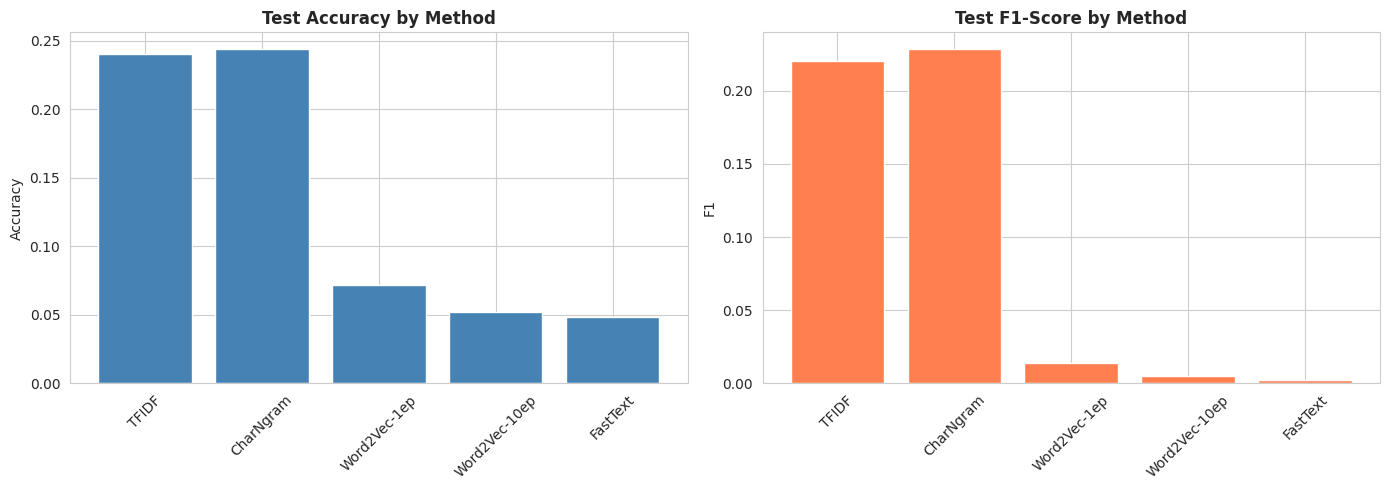

In [ ]:
# Cell 9 — Results summary and visualization
all_results = [result_tfidf, result_char, result_w2v1, result_w2v10, result_ft]

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('history', 'model_path')}
    for r in all_results
])[['tag', 'val_acc', 'val_f1', 'test_acc', 'test_f1']]

print('\n' + '='*60)
print('TASK 1 — FINAL RESULTS')
print('='*60)
print(results_df.to_string(index=False))

results_df.to_csv('/content/task1_results.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(results_df['tag'], results_df['test_acc'], color='steelblue')
axes[0].set_title('Test Accuracy by Method', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(results_df['tag'], results_df['test_f1'], color='coral')
axes[1].set_title('Test F1-Score by Method', fontweight='bold')
axes[1].set_ylabel('F1'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/task1_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Experiment Tracking — Logged at the End

The next cell logs all metrics, models, and artifacts to:
- **Weights & Biases**
- **Aim**
- **MLflow**


In [ ]:
# Initialize Aim repo properly
!aim init --repo /content/.aim

Aim repository is already initialized. Do you want to re-initialize to empty Aim repository? [y/N]: y
Re-initialized empty Aim repository at /content


In [14]:
# Cell 10 — Log everything to W&B, Aim, and MLflow


CONFIG = {
    'task': 'Task 1',
    'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 32,
    'hidden_size': 128, 'epochs': 50, 'num_classes': num_classes,
    'train_size': len(x_train), 'val_size': len(x_val), 'test_size': len(x_test)
}

# ── Setup ────────────────────────────────────────────────────
os.makedirs('/content/.aim',   exist_ok=True)
os.makedirs('/content/mlruns', exist_ok=True)
mlflow.set_tracking_uri('file:///content/mlruns')

wandb_key = getpass('Paste W&B API key (wandb.ai/authorize): ')
wandb.login(key=wandb_key)

# ── 1. Weights & Biases ──────────────────────────────────────
wandb.init(project='nalapro-swahili', name='task1-static-embeddings',
           config=CONFIG, reinit=True)
for res in all_results:
    h = res['history']
    for i, ep in enumerate(h['epoch']):
        wandb.log({
            f"{res['tag']}/train_loss": h['train_loss'][i],
            f"{res['tag']}/val_acc":    h['val_acc'][i],
            f"{res['tag']}/val_f1":     h['val_f1'][i],
            'epoch': ep
        })
    wandb.log({
        f"{res['tag']}/test_acc":     res['test_acc'],
        f"{res['tag']}/test_f1":      res['test_f1'],
        f"{res['tag']}/best_val_acc": res['val_acc'],
        f"{res['tag']}/best_val_f1":  res['val_f1']
    })
    art = wandb.Artifact(f"model-{res['tag']}", type='model')
    art.add_file(res['model_path']); wandb.log_artifact(art)

wandb.log({'task1_summary': wandb.Table(dataframe=results_df)})
wandb.log({'task1_chart':   wandb.Image('/content/task1_results.png')})
wandb_url = wandb.run.url
wandb.finish()

# ── 2. Aim ────────────────────────────────────────────────────
aim_run = aim.Run(experiment='nalapro-task1', repo='/content/.aim')
aim_run['hparams'] = CONFIG
for res in all_results:
    h = res['history']
    for i, ep in enumerate(h['epoch']):
        aim_run.track(h['train_loss'][i], name='train_loss', epoch=ep, context={'method': res['tag']})
        aim_run.track(h['val_acc'][i],    name='val_acc',    epoch=ep, context={'method': res['tag']})
        aim_run.track(h['val_f1'][i],     name='val_f1',     epoch=ep, context={'method': res['tag']})
    aim_run.track(res['test_acc'], name='test_acc', context={'method': res['tag']})
    aim_run.track(res['test_f1'],  name='test_f1',  context={'method': res['tag']})
aim_run.close()

# ── 3. MLflow ────────────────────────────────────────────────
mlflow.set_experiment('nalapro-task1-static')
for res in all_results:
    with mlflow.start_run(run_name=f"task1-{res['tag']}"):
        mlflow.log_params({**CONFIG, 'method': res['tag']})
        h = res['history']
        for i, ep in enumerate(h['epoch']):
            mlflow.log_metric('train_loss', h['train_loss'][i], step=ep)
            mlflow.log_metric('val_acc',    h['val_acc'][i],    step=ep)
            mlflow.log_metric('val_f1',     h['val_f1'][i],     step=ep)
        mlflow.log_metric('test_acc',     res['test_acc'])
        mlflow.log_metric('test_f1',      res['test_f1'])
        mlflow.log_metric('best_val_acc', res['val_acc'])
        mlflow.log_metric('best_val_f1',  res['val_f1'])
        mlflow.log_artifact(res['model_path'])

with mlflow.start_run(run_name='task1-summary'):
    mlflow.log_artifact('/content/task1_results.csv')
    mlflow.log_artifact('/content/task1_results.png')

print('\n' + '='*60)
print('✓ ALL TRACKING COMPLETE')
print('='*60)
print(f'W&B:    {wandb_url}')
print('Aim:    Run  !aim up --repo /content/.aim')
print('MLflow: Run  !mlflow ui --backend-store-uri /content/mlruns')


Paste W&B API key (wandb.ai/authorize): ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


CharNgram/best_val_acc,▁
CharNgram/best_val_f1,▁
CharNgram/test_acc,▁
CharNgram/test_f1,▁
CharNgram/train_loss,██▇▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CharNgram/val_acc,▁▄▅▆▆▇▇██████▇█▇████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
CharNgram/val_f1,▁▃▄▄▅▇▇▇▇████████████▇█▇████████████████
FastText/best_val_acc,▁
FastText/best_val_f1,▁
FastText/test_acc,▁
+26,...


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/20 19:40:07 INFO mlflow.tracking.fluent: Experiment with name 'nalapro-task1-static' does not exist. Creating a new experiment.



✓ ALL TRACKING COMPLETE
W&B:    https://wandb.ai/belinda-mziray-hochschule-luzern/nalapro-swahili/runs/njkn1rjn
Aim:    Run  !aim up --repo /content/.aim
MLflow: Run  !mlflow ui --backend-store-uri /content/mlruns
